In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return -x**3 +4*x +4

In [5]:
f(3.0)

-11.0

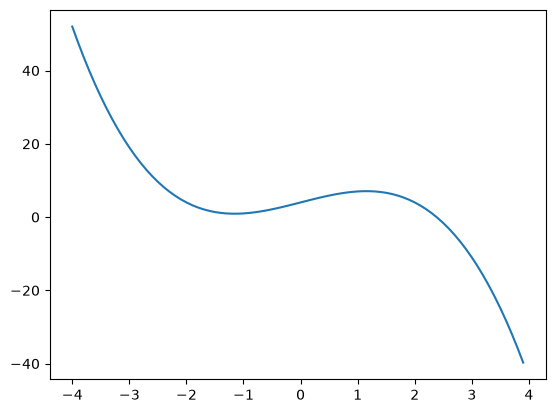

In [6]:
xs = np.arange(-4, 4, 0.1)
ys = f(xs)
plt.plot(xs, ys)

Definition of a derivative in a point of a function:

![derivative](../../imgs/derivative_point.png)



In [18]:
h = 0.0000001
a = 2.0

f(a)
f(a+h)
print('f(a) =', f(a))
print('f(a+h) =', f(a+h))

delta = f(a+h) - f(a)
print('Delta =', delta)
slope = (delta) / h
print('Derivative in a (slope) =', slope)

f(a) = 4.0
f(a+h) = 3.999999199999941
Delta = -8.000000590868694e-07
Derivative in a (slope) = -8.000000590868694


The derivative is the number I need to multiply the 'h' value for obtaining the delta.
$f'(a) * h = f'(a+h) - f(a)$. It helps us to normalize the derivative by the 'h' value

In [19]:
# lets get more complex
a = 2.0
b =  -4.0
c = 12.0

d = a*b + c
print('d =', d)

d = 4.0


In [21]:
h = 0.0001

# Inputs
a = 2.0
b =  -4.0
c = 12.0


# how much the value d changes if we change a by a small amount h

d2 = (a+h)*b + c
print('d2 =', d2)

d1 = a*b + c
print('d1 =', d1)

delta = d2 - d1
print('Delta =', delta)
slope = (delta) / h
print('Derivative in a (slope) =', slope)

d2 = 3.999599999999999
d1 = 4.0
Delta = -0.0004000000000008441
Derivative in a (slope) = -4.000000000008441


We computed the derivative of 'd' with respect 'a', how much change d when a small change is produced in the variable a.

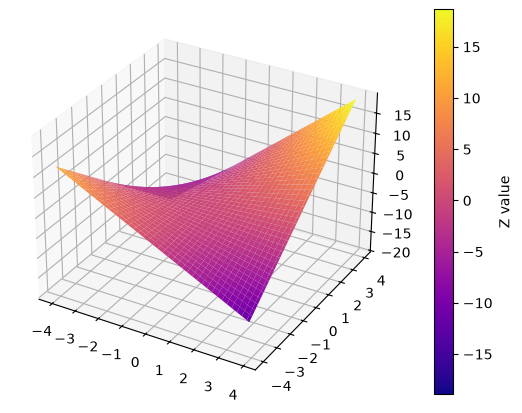

In [26]:
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection='3d')

# 1. Define your 1D axes
a = np.arange(-4, 4, 0.1)
b = np.arange(-4, 4, 0.1)
c = np.arange(-4, 4, 0.1)

# 2. Create a 2D grid out of them
A, B = np.meshgrid(a, b)

# 3. Calculate your Z-axis (height) using the grid
# Let's say C is a constant, or just omit it to do Z = A * B
Z = A * B + c

# 4. Plot as a surface
surface = ax.plot_surface(A, B, Z, cmap='plasma')

fig.colorbar(surface, label='Z value')
plt.show()

In [167]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0 # We assume that each value does not affect the output
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():

            self.grad += 1.0 * out.grad # We accumulate the gradients in case we use the same variable more than one time
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        
        
        return out



    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh' )

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward


        return out

    def backward(self):
        self.grad = 1.0

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)


        for node in reversed(topo):
            node._backward()    

a = Value(2.0, label = 'a')
b = Value(-4.0, label = 'b')
c = Value(12.0, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'


L

Value(data=-8.0)

In [ ]:
print(next(iter(d._prev))._op) # next(iter())  do not sustrate the element from the set, just return it
print(d._prev.pop()._op) # .pop() sustrate the element from the set and return it
#d._op

*
*


the 'd' element proceeded from a sum operation

In [83]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectanfular node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op) # Connecting the children nodes with the operation
    return dot

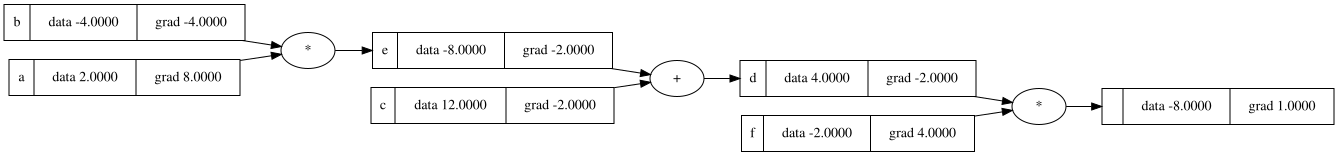

In [100]:
draw_dot(L)

The previous graph shows the forward step of the neural networks. Now, we will compute the gradient of each node. For example, for the node c, we need to compute the derivative respect the F.
These nodes represent the weights of a neural network, while the last one represent the value of the loss function.

In [101]:
# dL/dL = d(L)/dL = 1.0

L.grad = 1.0

In [89]:
L = d * f
# dL/dd = f The derivative of L respect d is f as we know for the definition
# dL/df = d the value of d is the derivative
f.grad = 4.0
d.grad = -2

In [ ]:
# dL/dc, also we need to know how is the dd/dc

# As, d = c + e
# (f(x+h) - f(x)) / h
# ((c+h + e)- (c+e))/ h
# h/h
# 1.0

# Then, the derivative of dd/dc = 1.0, and by simetry
# the derivative of dd/de = 1.0 too.

# These are called local derivatives

# Actually, we know the dL/dd and dd/dc as well as dd/de. However,
# we need to know the dL/dc so to do this we need to apply the chain rule

# WANT: dL/dc = (dL/dd)*(dd/dc). KNOW: dL/dd = -2, dd/dc = 1.0 

c.grad = -2.0 * 1.0 
e.grad = -2.0 * 1.0

# So in a sum node is like the gradient is routing backwards the next node as it is multiplied by 1.0

In [96]:
# dL/de = -2.0
# dL/da = (dL/de) * (de/da)

# e = a*b so de/da = b = -4.0
a.grad = -2.0 * -4.0

# dL/db = dL/de * de/db = -2.0 * a = -2.0 * 2.0
b.grad = -2.0 * 2.0

Since here, we have computed the gradients manually. Now, let's see what happens in the optimization process.

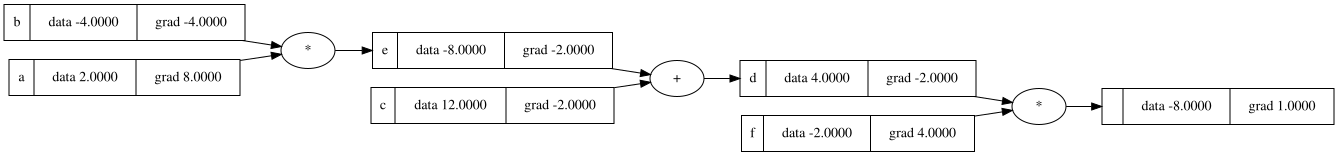

In [105]:
draw_dot(L)

A manual optimization step will be the following one.
We can see how to thank the gradient computed previously, we can change the final value according to that.

In [106]:
a.data += 0.01 * a.grad 
b.data += 0.01 * b.grad 
c.data += 0.01 * c.grad 
f.data += 0.01 * f.grad 

e = a * b
d = e + c
L = d * f

print(L.data)

-7.010528000000001


In [104]:
# Function to check the value of the gradient applying the definition of the derivative
# (f(x+h)-f(x)) /h
def lol():

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-4.0, label = 'b')
    c = Value(12.0, label = 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 + h, label = 'a')
    b = Value(-4.0, label = 'b')
    c = Value(12.0, label = 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)

lol()

8.000000000016882


Manual backpropagation but in a neuron

![neuron](../../imgs/neuron.png)

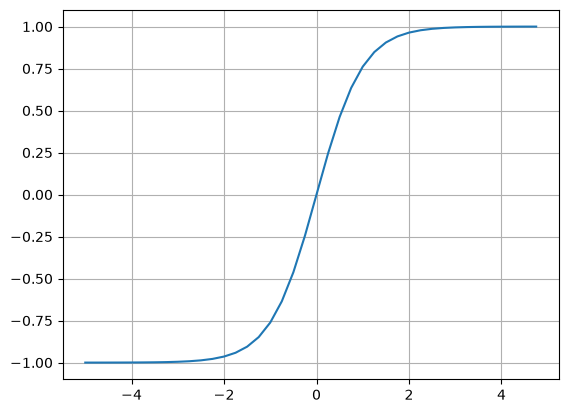

In [115]:
plt.plot(np.arange(-5,5,0.25), np.tanh(np.arange(-5,5,0.25))); plt.grid();

In [153]:
# inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weitghs, synapsis strength
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1+x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

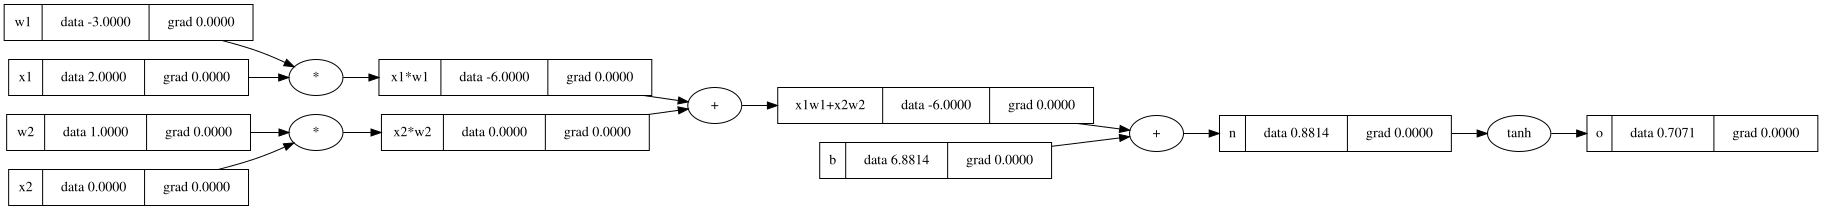

In [154]:
draw_dot(o)

### Backpropagation manually

In [119]:
o.grad = 1.0

In [120]:
# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1 - o**2 = 1 - 0.7071**2 = 0.5
n.grad = 0.5

In [122]:
# The next is a sum, and we know from the previous example that this is a distributive node
# n = x1w1x2w2 + b
# dn/db = 1.0
# do/db = do/dn * dn/db (chain rule) = 0.5 * 1.0 = 0.5
b.grad = 0.5

# then do/dx1w1x2w2 = do/dn * dn/dx1w1x2w2 = 0.5 * 1.0
x1w1x2w2.grad = 0.5

In [ ]:
# Now is another sum, so the same happens
# do/dx1w1 = do/dx1w1x2w2 * dx1w1x2w2/dx1w1 = 0.5 * 1.0, d(x1w1x2w2= x1w1 + x2w2)/dx1w1 = 1.0
x1w1.grad = 0.5
# the next is the same do/dx2w2 = 0.5
x2w2.grad = 0.5

In [126]:
# do/dx2 = do/dx2w2 * dx2w2/dx2 = 0.5 * 1.0 ; dx2w2/dx2 = (x2*w2)'=w2 = 1.0
x2.grad = 0.5
w2.grad = x2.data * x2w2.grad 

In [128]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

### Backprogation automatically

In [137]:
o.grad = 1.0 # Base case

In [138]:

o._backward()

In [140]:
n._backward()

In [142]:
x1w1x2w2._backward()

In [144]:
x2w2._backward()
x1w1._backward()

## Topological sort
We order the node to be able to apply the backward function over all the nodes

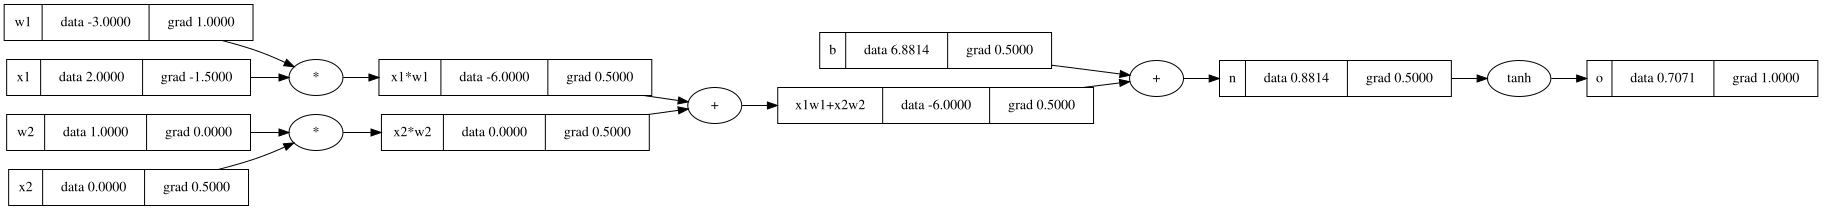

In [147]:
draw_dot(o)

In [149]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [151]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)


for node in reversed(topo):
    node._backward()

In [155]:
o.backward()

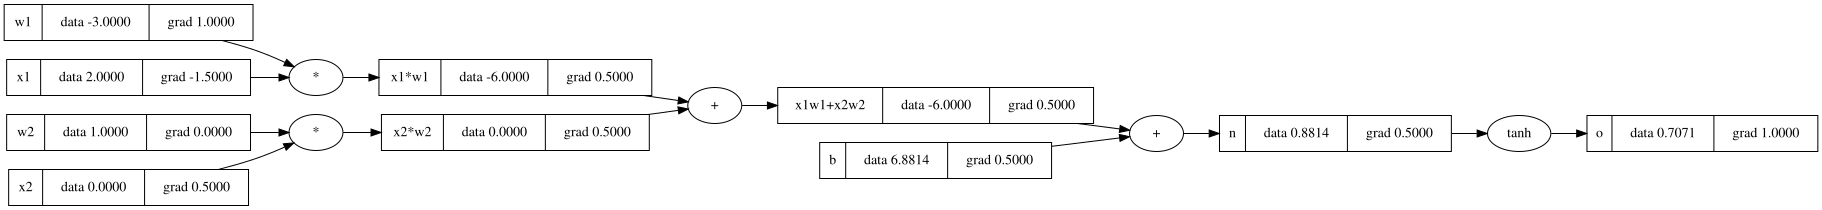

In [156]:
draw_dot(o)

## Fixing a bug

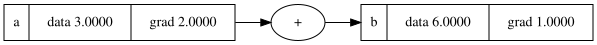

In [168]:
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()

draw_dot(b)

## Enhancing Value class

In [233]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0 # We assume that each value does not affect the output
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():

            self.grad += 1.0 * out.grad # We accumulate the gradients in case we use the same variable more than one time
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        
        
        return out

    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        other = other if isinstance(other, Value) else Value(other)
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out
    
    def __rmul__(self, other): # other * self
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other*((self.data)**(other-1))) * out.grad
        
        out._backward = _backward
        
        return out



    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __rtruediv__(self, other): # other / self
        other = other if isinstance(other, Value) else Value(other)
        out = Value((self.data**-1) * (other.data), (self, other,), '/')

    def __radd__(self, other): #other + self
        return self + other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh' )

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward


        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += (1.0*out.data) * out.grad
        out._backward = _backward

        return out
    


    def backward(self):
        self.grad = 1.0

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)


        for node in reversed(topo):
            node._backward()

In [170]:
a = Value(2.0)
a + 1

AttributeError: 'int' object has no attribute 'data'

In [ ]:
# We include the instance comprobation
a = Value(2.0)
a + 1
a*3
3*a



Value(data=6.0)

In [208]:
a = Value(2.0)
a.exp()

Value(data=7.38905609893065)

In [222]:
a = Value(2.0)
b = Value(4.0)
print(a / b)
print(a* 1 / b)
print(a* (b**-1))

a-b

0.5
0.5
Value(data=0.5)


Value(data=-2.0)

In [223]:
# inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weitghs, synapsis strength
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1+x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'
o.backward()

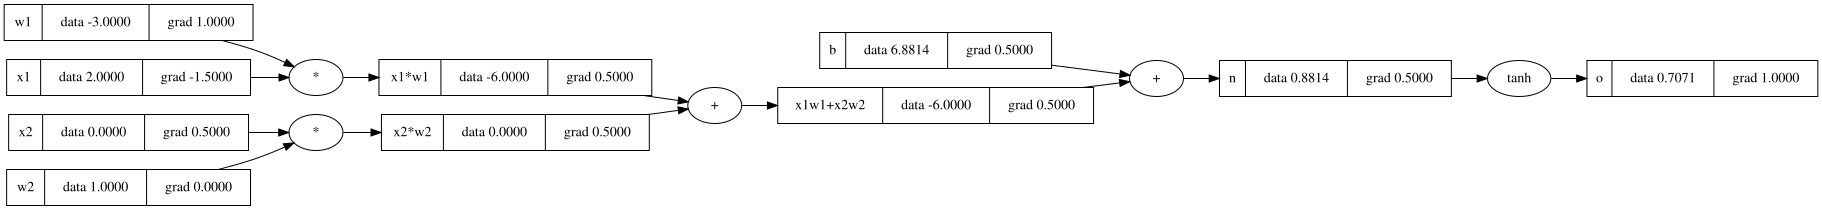

In [224]:
draw_dot(o)

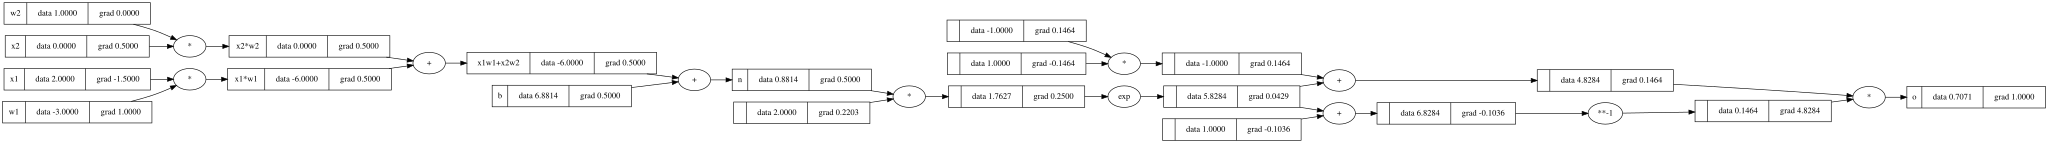

In [235]:
# inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weitghs, synapsis strength
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1+x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# -----
e = (n*2).exp()
o = (e - 1) / (e + 1)
# -----

o.label = 'o'
o.backward()
draw_dot(o)

# Now, let's do the same but in Pytorch

In [236]:
import torch



In [ ]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item()) # Forward Pass
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [238]:
o.item()

0.7071066904050358

## Building a neural network

In [292]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [293]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.6630116808741314)

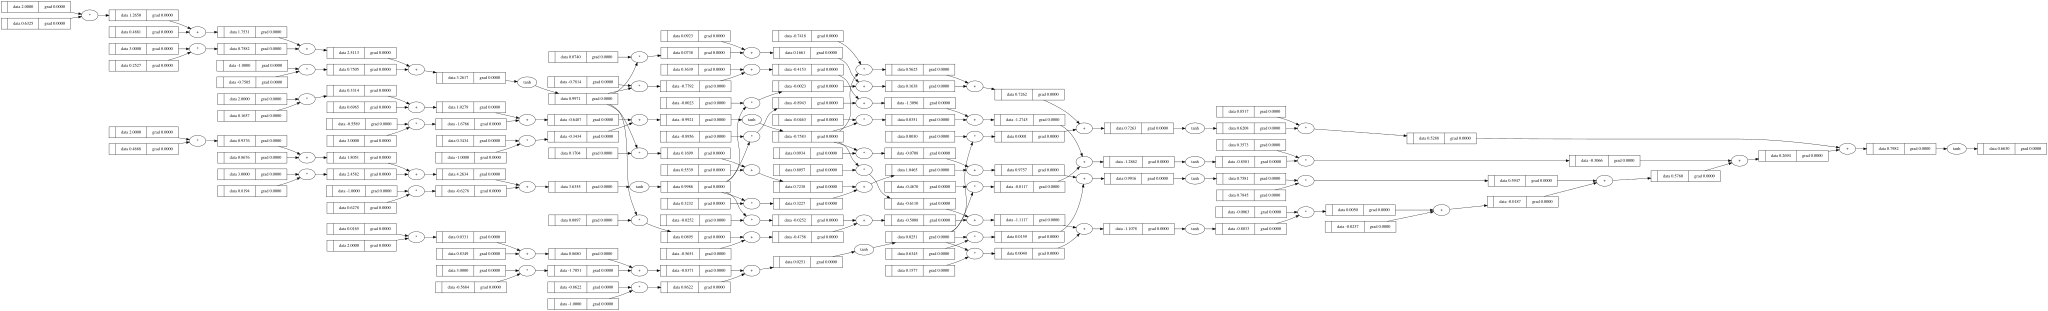

In [294]:
draw_dot(n(x))

# Writing a tiny dataset and a loss function

In [345]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [335]:
ypred = [n(x) for x in xs]  # FORWARD PASS
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.027215282479404027)

In [336]:
loss.backward() # BACKWARD PASS

In [337]:
for p in n.parameters():    # UPDATING WEIGHTS AND BIAS
    p.data += -0.01 * p.grad


In [338]:
ypred

[Value(data=0.9167176674418115),
 Value(data=-0.8992822335737811),
 Value(data=-0.9379654119513041),
 Value(data=0.9207095404552759)]

In [340]:
len(n.parameters())

41

In [347]:
for k in range(20):
    # GRADIENT DESCENT
    ypred = [n(x) for x in xs]  # FORWARD PASS
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad = 0.0 #  zero grad in pytorch
    loss.backward() # BACKWARD PASS

    for p in n.parameters():    # UPDATING WEIGHTS AND BIAS
        p.data += -0.01 * p.grad

    print(k, loss.data)

0 1.7763851309732064e-06
1 1.776048755223969e-06
2 1.7757125207703634e-06
3 1.7753764275210558e-06
4 1.775040475385316e-06
5 1.7747046642715193e-06
6 1.7743689940889544e-06
7 1.774033464745597e-06
8 1.7736980761513314e-06
9 1.773362828215017e-06
10 1.7730277208458015e-06
11 1.772692753952284e-06
12 1.7723579274451786e-06
13 1.7720232412331056e-06
14 1.7716886952253896e-06
15 1.7713542893319196e-06
16 1.7710200234617926e-06
17 1.7706858975255099e-06
18 1.7703519114325096e-06
19 1.7700180650925517e-06


In [348]:
ypred

[Value(data=0.9999261039068763),
 Value(data=-0.99867527060248),
 Value(data=-0.9999339942010621),
 Value(data=0.9999272491211987)]